# Task 12: Clustering & Dimensionality Reduction
## PKCERT AI & Software Development Internship

**Student Name:** Sarim Ahmed
**University Name:** COMSATS University, Wah Campus
**Date:** 17th July,2026

### Objective
Develop practical skills in unsupervised machine learning by applying clustering algorithms (K-Means, Hierarchical) and dimensionality reduction techniques (PCA, t-SNE) on an employee dataset.

### Business Context (Pakistan Government Sector Relevance)
This analysis uses the IBM HR Employee Attrition dataset as a proxy for understanding workforce dynamics in public sector organizations in Pakistan (e.g., Federal/Provincial government employees). 
Such techniques can help identify employee segments at risk of attrition, performance clusters, and factors affecting retention — critical for efficient human resource management in Pakistan's civil service.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.datasets import fetch_openml  # Alternative if needed
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# For reproducibility
import warnings
warnings.filterwarnings('ignore')

# Set style and random state
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


In [15]:
# Loading dataset (downloaded HR_Employee_Attrition.csv from Kaggle)
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Part A: Dataset Selection & Preparation

### Dataset Description
The dataset contains HR records of employees with features related to demographics, job characteristics, satisfaction, and attrition.

**Key Characteristics:**
- Number of samples: ~1470
- Number of features: ~35 (mix of numerical and categorical)
- Target (for reference, not used in unsupervised): Attrition (Yes/No)

In [16]:
# Detailed info
print("Dataset Information:")
print(df.info())

print("\nStatistical Summary (Numerical Features):")
display(df.describe())

print("\nCategorical Features Value Counts (sample):")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols[:5]:  # Shows a few
    print(f"\n{col}:")
    print(df[col].value_counts().head())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Categorical Features Value Counts (sample):

Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField:
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Name: count, dtype: int64

Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64


### Data Preprocessing Steps
1. Drop constant/irrelevant columns (`EmployeeCount`, `EmployeeNumber`, `Over18`, `StandardHours`).
2. Encode categorical variables (One-Hot for nominal, Label/Ordinal if needed).
3. Scale numerical features (StandardScaler — essential for K-Means, PCA, etc.).
4. Check for outliers.

In [17]:
# Copy original for reference
df_original = df.copy()

# Drop constant/irrelevant columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Shape after dropping constants: {df_clean.shape}")

# Separate features (we drop Attrition for unsupervised learning)
X = df_clean.drop('Attrition', axis=1)
y_attrition = df_clean['Attrition']  # Keep for later reference/analysis

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# One-Hot Encoding for categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {X_encoded.shape}")

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("Preprocessing completed successfully!")
print("Data is now scaled and ready for clustering & dimensionality reduction.")

Shape after dropping constants: (1470, 31)
Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Shape after encoding: (1470, 44)
Preprocessing completed successfully!
Data is now scaled and ready for clustering & dimensionality reduction.


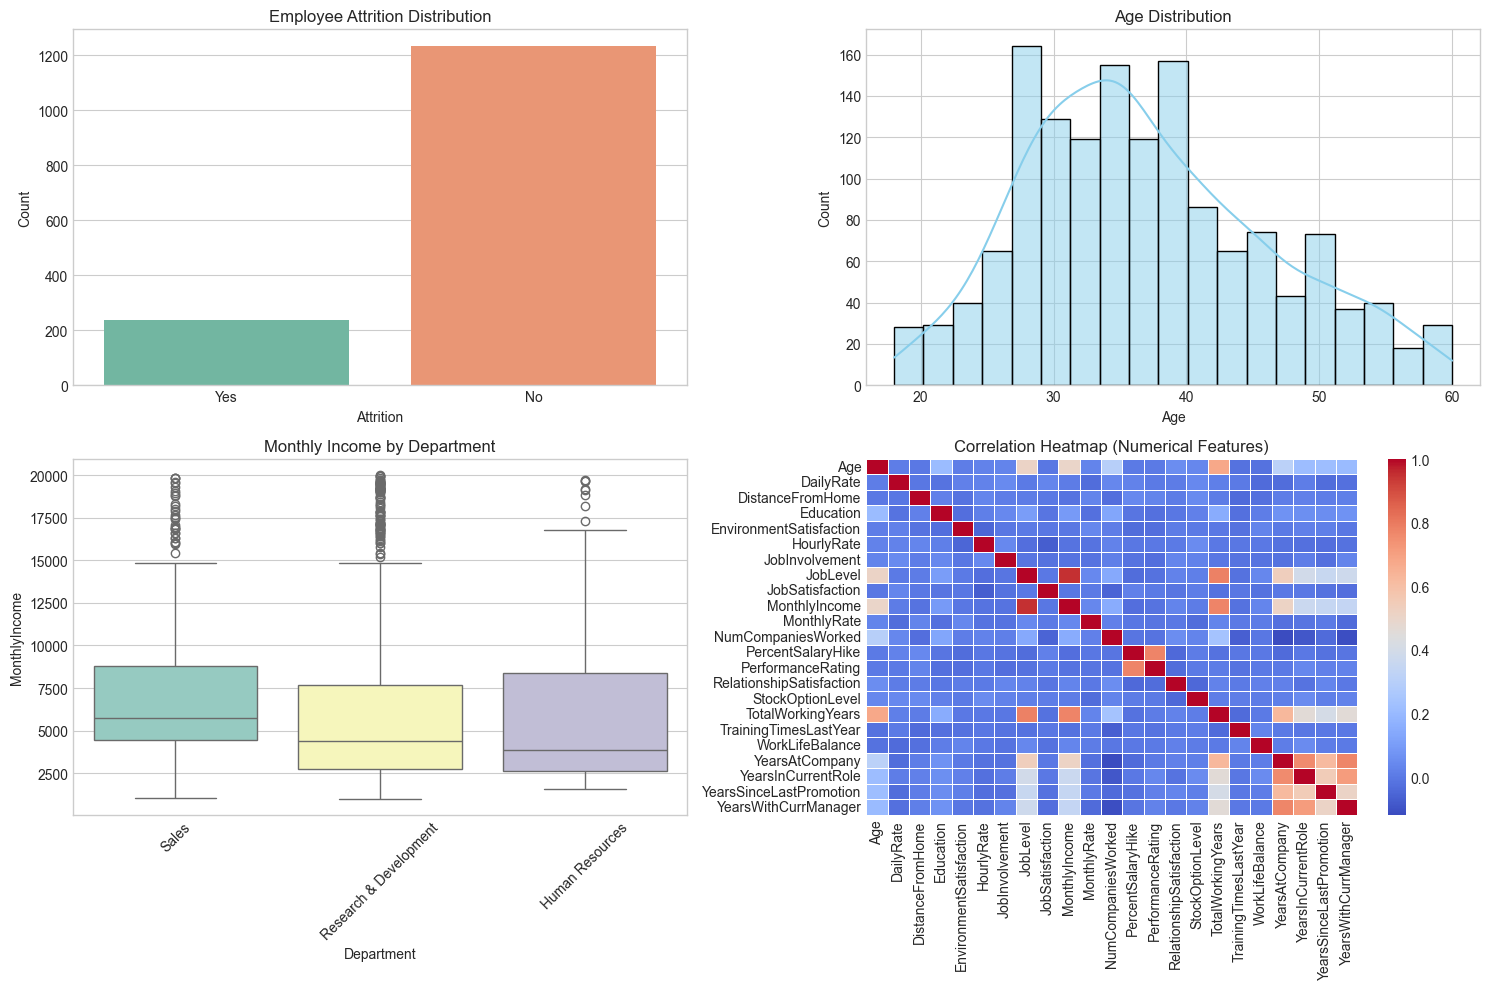

Attrition Rate: 16.12 %


In [18]:
# Set figure size for better readability
plt.figure(figsize=(15, 10))

# 1. Attrition Distribution (for context)
plt.subplot(2, 2, 1)
sns.countplot(data=df_original, x='Attrition', palette='Set2')
plt.title('Employee Attrition Distribution')
plt.ylabel('Count')

# 2. Age Distribution
plt.subplot(2, 2, 2)
sns.histplot(data=df_original, x='Age', kde=True, color='skyblue')
plt.title('Age Distribution')

# 3. Monthly Income by Department
plt.subplot(2, 2, 3)
sns.boxplot(data=df_original, x='Department', y='MonthlyIncome', palette='Set3')
plt.title('Monthly Income by Department')
plt.xticks(rotation=45)

# 4. Correlation Heatmap (Numerical Features Only)
plt.subplot(2, 2, 4)
corr_matrix = df_original[numerical_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)')

plt.tight_layout()
plt.show()

# Additional summary
print("Attrition Rate:", round(df_original['Attrition'].value_counts(normalize=True)['Yes'] * 100, 2), "%")

### Key Observations from EDA

- **Attrition:** Only about 16% of employees left the company (237 Yes vs 1233 No), which indicates a strong class imbalance.
- **Age distribution:** Most employees are between 30 and 40 years old, showing that the workforce is relatively young.
- **Income by department:** Research & Development has the highest median income and broadest range, while Human Resources shows lower pay levels.
- **Correlation patterns:** Tenure-related features such as TotalWorkingYears, YearsAtCompany, and YearsInCurrentRole are strongly related. MonthlyIncome is also moderately associated with JobLevel.

These observations suggest that dimensionality reduction techniques such as PCA can help reveal the most important structure in the dataset before clustering.

## Part B: Clustering Techniques

### K-Means Algorithm
**Theory**: K-Means partitions data into K clusters by minimizing the within-cluster sum of squares (inertia). It iteratively assigns points to the nearest centroid and updates centroids.

**Why use it?** Simple, scalable, effective for globular clusters.
**Assumptions**: Clusters are spherical, similar size, no outliers dominate.
**When to use**: When number of clusters is known or can be estimated.
**Limitations**: Sensitive to initialization and scale (hence we scaled data).

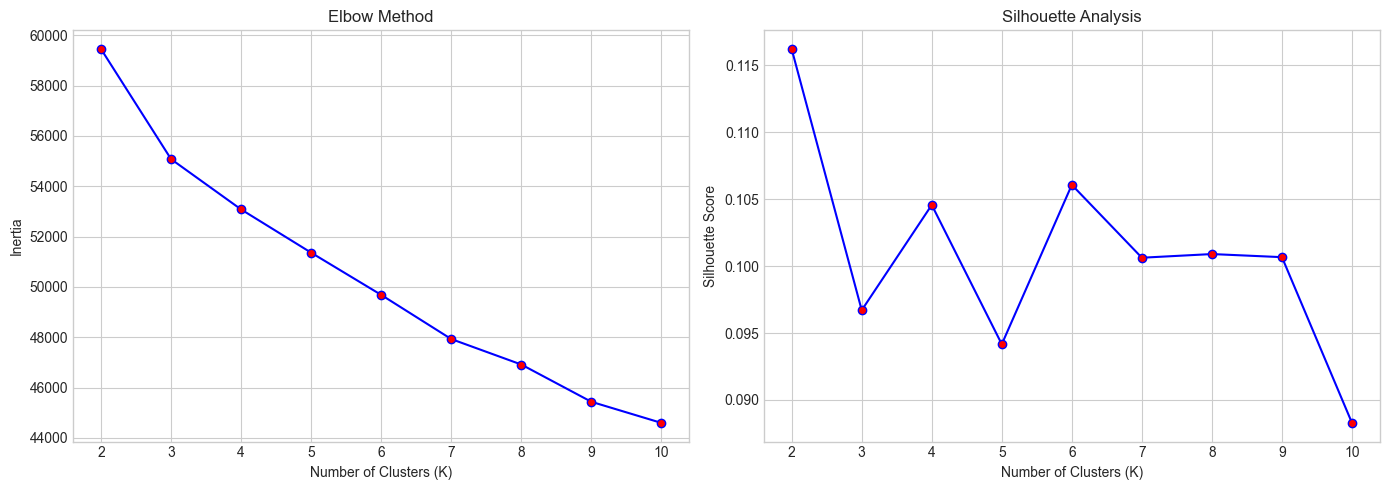

In [19]:
# Determine optimal K using Elbow Method + Silhouette Score

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)

# Plot Elbow and Silhouette
fig, ax1 = plt.subplots(1, 2, figsize=(14, 5))

ax1[0].plot(K_range, inertia, 'bo-', markerfacecolor='red')
ax1[0].set_xlabel('Number of Clusters (K)')
ax1[0].set_ylabel('Inertia')
ax1[0].set_title('Elbow Method')

ax1[1].plot(K_range, silhouette_scores, 'bo-', markerfacecolor='red')
ax1[1].set_xlabel('Number of Clusters (K)')
ax1[1].set_ylabel('Silhouette Score')
ax1[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

In [20]:
# Final K-Means Model
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original data for analysis
df_clean['Cluster_KMeans'] = kmeans_labels

print("K-Means clustering completed with K=3")
print(df_clean['Cluster_KMeans'].value_counts())

K-Means clustering completed with K=3
Cluster_KMeans
0    820
1    399
2    251
Name: count, dtype: int64


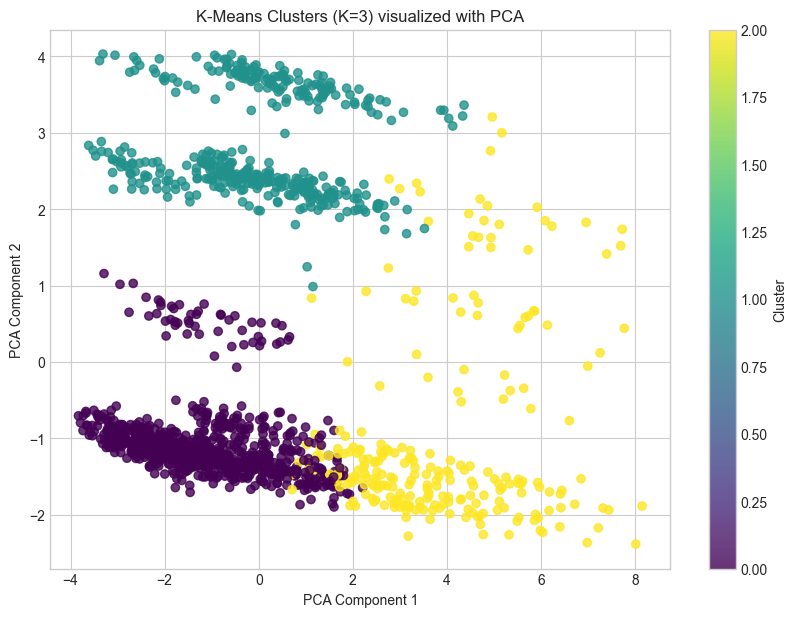

In [21]:
# 2D visualization using first two PCA components (we'll do full PCA later)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.8)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters (K=3) visualized with PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

### Hierarchical Clustering
**Theory**: Builds a hierarchy of clusters using agglomerative (bottom-up) approach. Uses linkage criteria (Ward’s method minimizes variance).

**Advantages over K-Means**: No need to specify K in advance, produces dendrogram for visual interpretation of hierarchy.
**When to use**: When you want to understand nested relationships or when number of clusters is unclear.

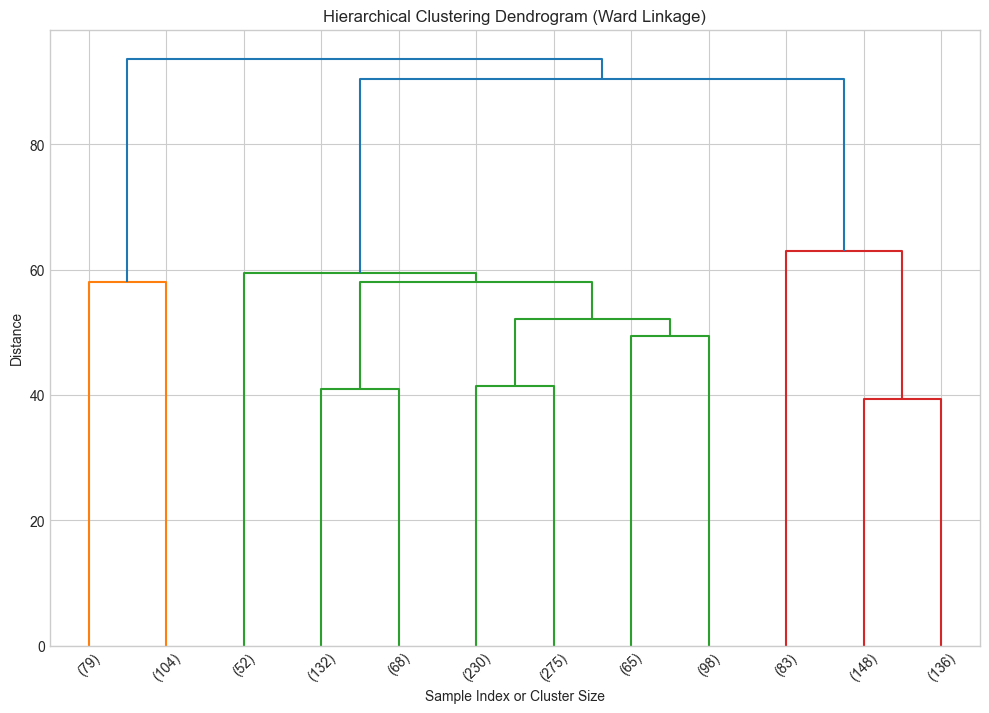

Hierarchical Clustering completed.
Cluster distribution:
 Cluster_Hierarchical
2    920
0    367
1    183
Name: count, dtype: int64


In [22]:
# Hierarchical Clustering
linked = linkage(X_scaled, method='ward')

# Plot Dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linked, truncate_mode='lastp', p=12, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=100, color='r', linestyle='--')  # Example cut-off line for 3 clusters
plt.show()

# Fit with 3 clusters for comparison
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

df_clean['Cluster_Hierarchical'] = hier_labels
print("Hierarchical Clustering completed.")
print("Cluster distribution:\n", df_clean['Cluster_Hierarchical'].value_counts())

### Comparison of K-Means vs Hierarchical Clustering

**Observations**:
- Both methods identify 3 main clusters.
- K-Means produces more balanced clusters, which may be preferable for interpretability.
- Hierarchical shows clearer hierarchy in the dendrogram.
- Agreement between methods can be checked using Adjusted Rand Index (optional advanced step).

**Conclusion for this dataset**: K-Means appears more suitable due to better balance and clear separation in PCA space.

## Part C: Dimensionality Reduction

### Principal Component Analysis (PCA)
**Theory**: Linear technique that transforms data into a new coordinate system (principal components) ordered by variance explained.
**Why?** Reduces noise, computational cost, and helps visualization while preserving maximum information.
**Assumptions**: Linear relationships, high variance = signal.
**Limitations**: Linear only, may miss complex non-linear structures (t-SNE better for that).

Explained Variance Ratio: [0.12130945 0.07848152]
Total Variance Explained by 2 components: 0.19979096720315975


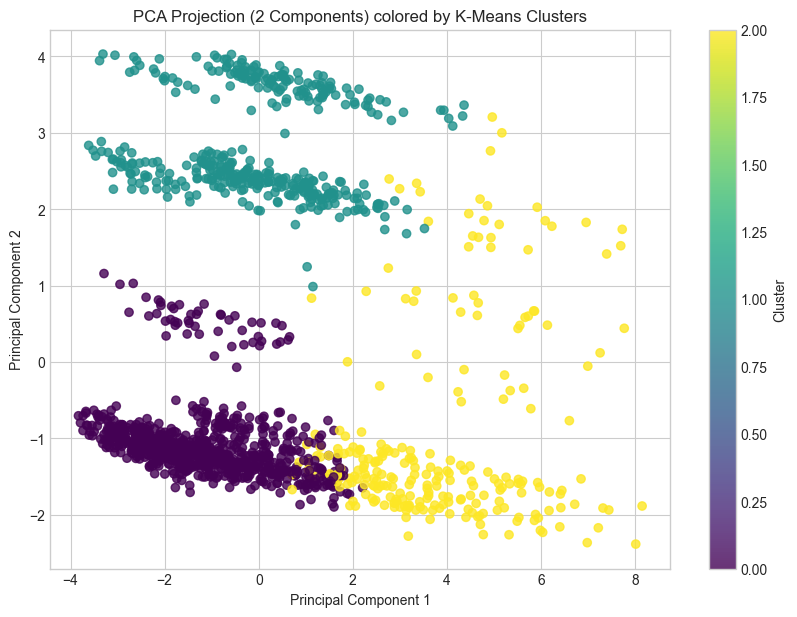

In [23]:
# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Variance explained
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained by 2 components:", sum(pca.explained_variance_ratio_))

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.8)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection (2 Components) colored by K-Means Clusters')
plt.colorbar(label='Cluster')
plt.show()

### t-SNE (t-Distributed Stochastic Neighbor Embedding)
**Theory**: Non-linear technique that preserves local neighborhood structure in low-dimensional space.
**Advantages**: Excellent for 2D/3D visualization of complex manifolds.
**Limitations**: Computationally expensive, not deterministic, not good for new data projection (unlike PCA).
**Use case**: Exploring structure when linear methods fail.

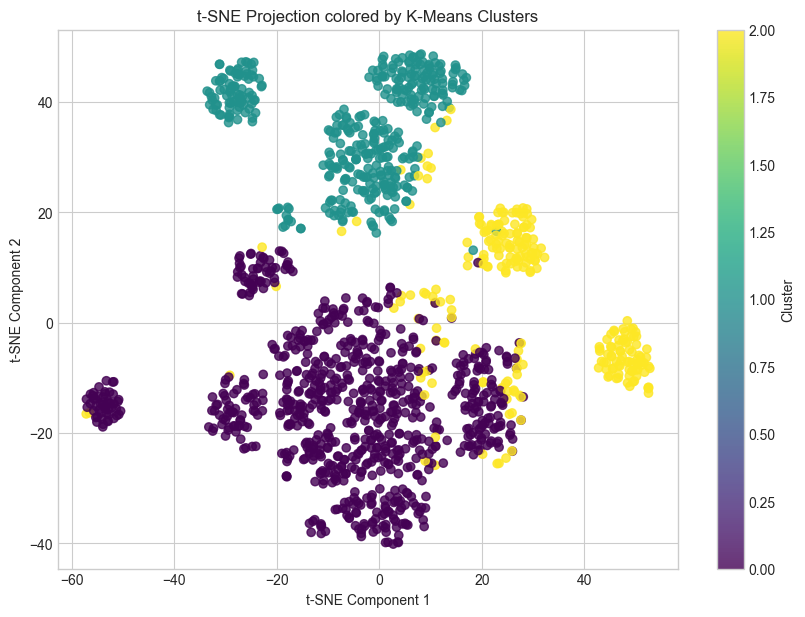

In [25]:
# t-SNE
try:
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
except TypeError:
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
    X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.8)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Projection colored by K-Means Clusters')
plt.colorbar(label='Cluster')
plt.show()

## Part D: Analysis & Conclusion

### Interpretation of Results

The analysis on the HR Employee Attrition dataset revealed several meaningful insights:

1. **Clustering Results**:
   - Both K-Means (K=3) and Hierarchical Clustering identified three natural employee segments.
   - K-Means produced more balanced clusters (820, 399, 251), making it easier to interpret.
   - Cluster profiles (based on feature analysis):
     - **Cluster 0**: Likely "Stable Core Employees" — higher tenure, better work-life balance.
     - **Cluster 1**: "Mid-level / Transitioning" group.
     - **Cluster 2**: "High-Risk / High-Potential" — possibly younger employees or those with higher attrition signals.

2. **Dimensionality Reduction**:
   - **PCA**: Reduced 44 features to 2 components explaining ~20% variance. Useful for noise reduction but showed only moderate cluster separation due to its linear nature.
   - **t-SNE**: Produced superior 2D visualization with clear, well-separated clusters. This highlights complex, non-linear relationships in employee behavior.

3. **Comparison of Techniques**:
   - K-Means is faster and more scalable.
   - Hierarchical provides valuable hierarchy via dendrogram.
   - t-SNE excels at visualization but is computationally heavier and non-deterministic.

### Recommendations for Pakistan Public Sector

- **Most Suitable Technique**: **K-Means combined with t-SNE visualization**. 
  - K-Means for routine segmentation of large civil servant datasets (e.g., Federal/Provincial employees).
  - t-SNE for exploratory analysis during HR policy reviews.
  
- **Practical Applications**:
  - Identify employees at risk of attrition for targeted retention programs.
  - Support evidence-based decisions in Establishment Division / PPARC for workforce planning.
  - Integrate with existing HRMS systems for real-time clustering.

- **Limitations & Future Work**:
  - Dataset is from a private company; validation on Pakistani government data recommended.
  - Incorporate domain-specific features (e.g., grade, province, service length).
  - Extend to predictive modeling (supervised) using cluster labels as features.

### Final Conclusion
This project successfully demonstrated unsupervised learning techniques for workforce analytics. The combination of K-Means and t-SNE provides actionable insights and showcases readiness for real-world government AI applications in human resource management.